In [27]:
from astropy.io import ascii

import os
import sys
import glob
import numpy as np
from tqdm import trange
from astropy.io import fits
from astropy.table import Table, vstack, hstack
from astropy.convolution import convolve, Gaussian1DKernel
import astropy.units as u
import astropy.coordinates as coord
import matplotlib
import matplotlib.pyplot as plt
from astropy.table import Column
from tqdm import trange
import pandas as pd
import fitsio
from astropy.table import Table, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord
from easyquery import Query, QueryMaker
from scipy.stats import binomtest
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm
import h5py
from astropy.cosmology import Planck18

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs
from desi_lowz_funcs import calc_normalized_dist
from desi_lowz_funcs import find_objects_nearby
# from construct_dwarf_galaxy_catalogs import process_sga_matches
from catalog_paper_plots import make_bar_pie


%load_ext autoreload
%autoreload 2

    

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# from consolidate_photometry import get_fastspec_fit_catalog_V2

In [3]:
# get_fastspec_fit_catalog_V2()

In [2]:
filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# Option 1: load the MAIN extension directly as an Astropy Table
main =  Table.read(filename, hdu="MAIN")
fastspec =  Table.read(filename, hdu="FASTSPEC")


In [28]:
main = hstack([main, fastspec["HALPHA_EW"]])

In [37]:
len(main[main["SAMPLE"] == "ELG"])

149922

In [46]:
temp = main[(main["SAMPLE"] == "ELG") & (fastspec["HALPHA_EW"] > 0) & ( fastspec["HALPHA_EW"] * np.sqrt(fastspec["HALPHA_EW_IVAR"]) < 3 ) ]["RA","DEC","HALPHA_EW","TARGETID"]





In [45]:
np.percentile(temp["HALPHA_EW"], [16,50,84,95])

0.3169737792015076
1.8508414030075073
75.1191143798828
250.9613494873046


In [3]:
# spectra_h5_path = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/spectra_files/data/desi_dr1_dwarf_catalog_spectra.h5"

# with h5py.File(spectra_h5_path, "r") as f:
#     h5_wave = f["WAVE"][:]
#     h5_flux = f["FLUX"][:]
#     h5_flux_ivar = f["FLUX_IVAR"][:]
#     h5_targetid = f["TARGETID"][:]

In [7]:
main[:2]

TARGETID,SURVEY,PROGRAM,HEALPIX,Z,DELTACHI2,ZWARN,Z_CMB,RA,DEC,RA_TARGET,DEC_TARGET,DESINAME,LUMI_DIST_MPC,DIST_SOURCE,LOG_MSTAR_SAGA,LOG_MSTAR_M24,MAG_G,MAG_R,MAG_Z,MAG_G_TARGET,MAG_R_TARGET,MAG_Z_TARGET,SAMPLE,DWARF_MASKBIT,MAG_TYPE,PHOTOMETRY_UPDATED,R50_R,SHAPE_PARAMS,IN_SGA_2020,ASSOCIATED_TARGETIDS,DWARF_PRIMARY_TARGETID,DWARF_PRIMARY
int64,bytes7,bytes6,int32,float64,float64,bool,float64,float64,float64,float64,float64,bytes22,float64,bytes10,float64,float64,float64,float64,float64,float64,float64,float64,bytes10,int32,bytes13,bool,float64,float64[2],bool,object,int64,bool
39627066986994125,sv1,bright,34722,0.032918604316881296,98.85089745232835,False,0.03264401958193863,58.82791003142589,-31.167992883134954,58.82791003142589,-31.167992883134954,DESI J058.8279-31.1679,148.21792602539062,V_CMB,8.833382057755909,8.893782877718312,18.319110870361328,17.939651489257812,17.730533599853516,18.319110870361328,17.939651489257812,17.730533599853516,BGS_BRIGHT,0,TRACTOR_OG,False,7.116967678070068,0.6592394709587097 .. -87.19556427001953,False,[],39627066986994125,True
39627067007963313,sv1,bright,34721,0.07121362839646002,2014.0257760286331,False,0.07095510690031337,60.226366678070214,-31.212205289954937,60.226366678070214,-31.212205289954937,DESI J060.2263-31.2122,331.0528564453125,V_CMB,9.077966582250141,9.125664686038139,19.44179344177246,19.06585693359375,18.83696174621582,19.44179344177246,19.06585693359375,18.83696174621582,BGS_BRIGHT,0,TRACTOR_OG,False,1.4997080564498901,0.5409847497940063 .. -19.329486846923828,False,[],39627067007963313,True


## Get Fastspec model continuum photometry

STEPS: read in the emission line model from fastspec and subtract it from teh real data
and then measure the photometry on it? compare that with photometry on the model continuum fit? Do they agree pretty well??
what about colors? it is pretty easy to do both!! but just to make sure 


In [5]:
len(main)

410604

In [5]:
from fastspec_funcs import compute_photometry_catalog

In [8]:
## maybe let us select the subset where HALPHA_EW is well detected and BGS BRIGHT?

ew_snr = np.array(fastspec["HALPHA_EW"]) * np.sqrt(np.array(fastspec["HALPHA_EW_IVAR"]))

main_i = main[(ew_snr > 5) & (main["DELTACHI2"] > 100) & (main["SAMPLE"] == "BGS_BRIGHT") & (fastspec["SNR_R"] > 3) & (fastspec["SNR_Z"] > 3) ]

# main_elg = main[(main["SAMPLE"] == "ELG") & (main["DELTACHI2"] > 100) ]

print(len(main_i))
# print(len(main_elg))


51749


In [127]:
result = compute_photometry_catalog(
    main_i[:100],
    spectra_h5_path="/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/spectra_files/data/desi_dr1_dwarf_catalog_spectra.h5",
    compute_data_photometry=True,
    save_path=None,
)

# "/pscratch/sd/v/virajvm/trash/test_mag_diff.fits"


Loading observed spectra from /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/spectra_files/data/desi_dr1_dwarf_catalog_spectra.h5 ...
  Loaded 381740 spectra, wave shape (7781,)
Total objects: 100, unique FITS files: 42
Done. 100/100 with valid model photometry, 100/100 with valid absolute mags. 78/100 with valid data photometry.


In [116]:
result = compute_photometry_catalog(
    main_elg[:500],
    spectra_h5_path="/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/spectra_files/data/desi_dr1_dwarf_catalog_spectra.h5",
    compute_data_photometry=True,
    save_path=None,
)


Loading observed spectra from /pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/spectra_files/data/desi_dr1_dwarf_catalog_spectra.h5 ...
  Loaded 381740 spectra, wave shape (7781,)
Total objects: 500, unique FITS files: 201
  Processed 50/201 files


/global/common/software/desi/perlmutter/desiconda/20240425-2.2.0/code/speclite/main/speclite/filters.py:1119: RuntimeWarning: invalid value encountered in log10
  return -2.5 * np.log10(maggies)


  Processed 100/201 files
  Processed 150/201 files
  Processed 200/201 files
Done. 500/500 with valid model photometry, 500/500 with valid absolute mags. 492/500 with valid data photometry.


In [128]:
### the hope is that the photometry does not differ much ... 
result[:3]

TARGETID,g_model_no_emi,r_model_no_emi,g_model_w_emi,r_model_w_emi,ABSMAG01_SYNTH_SDSS_G,ABSMAG01_SYNTH_SDSS_R,ABSMAG01_SYNTH_IVAR_SDSS_G,ABSMAG01_SYNTH_IVAR_SDSS_R,g_data_no_emi,r_data_no_emi,g_data_w_emi,r_data_w_emi
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
39627067007963313,20.455376058210586,20.111004847520412,20.396108261398904,20.073696035434732,-17.160633087158203,-17.52100372314453,9120.974609375,47903.1640625,20.496598929885348,20.14576674023357,20.435101090888406,20.107266228126434
39627077376288706,19.89703016863102,19.58018133129742,19.855711578779907,19.537471377313544,-17.24690055847168,-17.591533660888672,11153.39453125,199527.515625,nan,nan,nan,nan
39627082573030107,19.59077349342111,19.348897927486043,19.558596052166482,19.312139322225367,-16.95887565612793,-17.24503517150879,12340.9208984375,102774.921875,19.633890696257986,19.361431565847404,19.6004298154865,19.32425346130081


In [129]:
np.sqrt(1/47903.1640625)

0.00456896572349062

In [130]:
g_model_diff = result["g_model_no_emi"].data - result["g_model_w_emi"].data
g_data_diff = result["g_data_no_emi"].data - result["g_data_w_emi"].data

r_model_diff = result["r_model_no_emi"].data - result["r_model_w_emi"].data
r_data_diff = result["r_data_no_emi"].data - result["r_data_w_emi"].data

gr_model_w_emi = result["g_model_w_emi"].data - result["r_model_w_emi"].data
gr_model_no_emi = result["g_model_no_emi"].data - result["r_model_no_emi"].data

gr_data_w_emi = result["g_data_w_emi"].data - result["r_data_w_emi"].data
gr_data_no_emi = result["g_data_no_emi"].data - result["r_data_no_emi"].data

gr_model_diff = gr_model_no_emi - gr_model_w_emi
gr_data_diff = gr_data_no_emi - gr_data_w_emi


In [131]:
# 39627380339251819
## some things to look into
## what happens to model fit if spectra is negative -> model fit continuum is always +ve
## what about poor fastspec fit ?? -> fit error will be in absmag synth ...
## we could at the end make a plot of HALPHA_EW to the photometry changes -> 
## and if things are very noisy are something make cuts there??

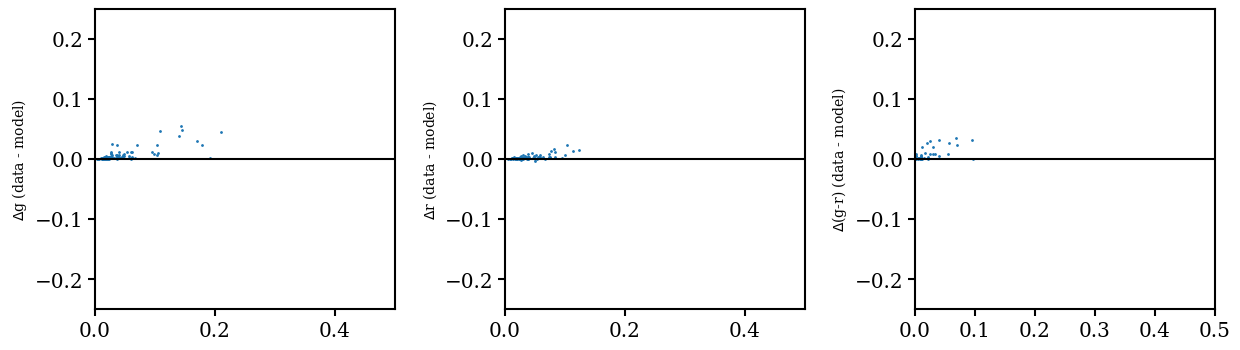

In [132]:
fig,ax = make_subplots(ncol=3,nrow=1,return_fig=True)

ax[0].scatter( g_model_diff, g_data_diff - g_model_diff,s=1 )
ax[1].scatter( r_model_diff, r_data_diff - r_model_diff,s=1 )
ax[2].scatter( gr_model_diff,  gr_data_diff - gr_model_diff,s=1 )

ax[0].set_ylabel(r"$\Delta$g (data - model)")
ax[1].set_ylabel(r"$\Delta$r (data - model)")
ax[2].set_ylabel(r"$\Delta$(g-r) (data - model)")


for axi in ax:
    axi.plot([0,1],[0,0],color="k")
    axi.set_xlim([0.0,.5])
    axi.set_ylim([-.25,.25])

plt.show()


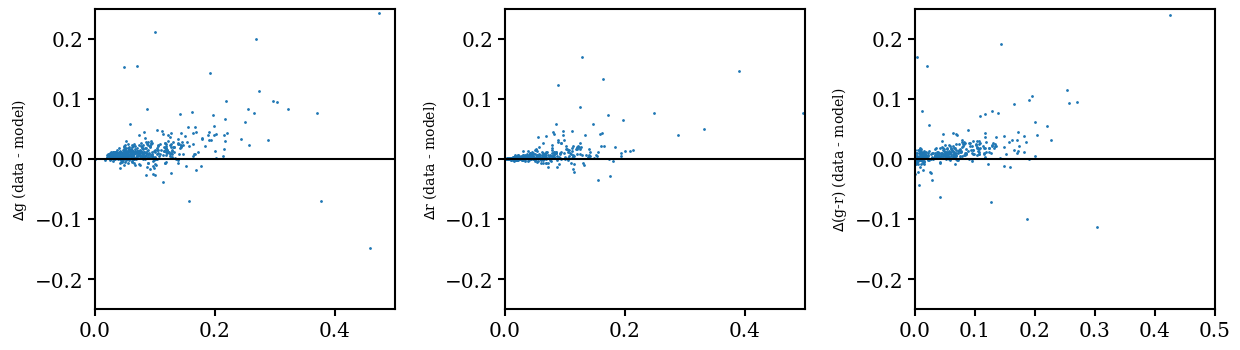

In [124]:
fig,ax = make_subplots(ncol=3,nrow=1,return_fig=True)

ax[0].scatter( g_model_diff, g_data_diff - g_model_diff,s=1 )
ax[1].scatter( r_model_diff, r_data_diff - r_model_diff,s=1 )
ax[2].scatter( gr_model_diff,  gr_data_diff - gr_model_diff,s=1 )

ax[0].set_ylabel(r"$\Delta$g (data - model)")
ax[1].set_ylabel(r"$\Delta$r (data - model)")
ax[2].set_ylabel(r"$\Delta$(g-r) (data - model)")


for axi in ax:
    axi.plot([0,1],[0,0],color="k")
    axi.set_xlim([0.0,.5])
    axi.set_ylim([-.25,.25])

plt.show()


In [2]:
cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_bgs_bright_filter_zsucc_zrr02_allfracflux_INT_V2_NEBCORR.fits")

snr_mask  =  ( (cat["HALPHA_EW"].data * np.sqrt(cat["HALPHA_EW_IVAR"]) ) > 5) & (cat["HALPHA_EW"] > 0)

In [3]:
np.sum(snr_mask)/len(snr_mask)

0.8637257623454785

In [4]:

from desi_lowz_funcs import get_contours

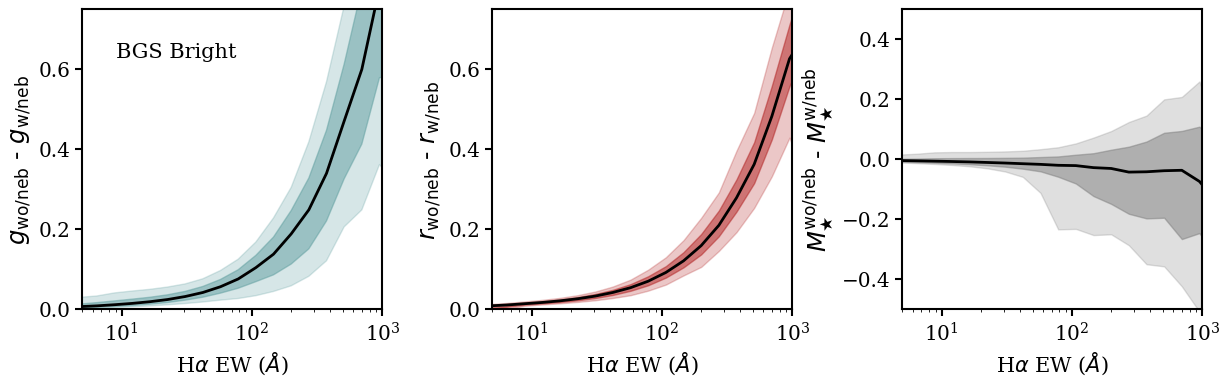

In [19]:
import numpy as np

fig, ax = make_subplots(ncol=3, nrow=1, return_fig=True)

# Log-spaced x bins
x_bins = np.logspace(np.log10(4), np.log10(1.5e3), 20)

# Panel 0
x0 = cat["HALPHA_EW"].data[snr_mask]
y0 = cat["DELTA_MAG_G_NEB"].data[snr_mask]
c0 = get_contours(x0, y0, x_bins, sigs=True)
col0 = "cadetblue"
ax[0].plot(c0["bin_cents"], c0["median"], color="k", lw=2)
ax[0].fill_between(c0["bin_cents"], c0["sig1_low"], c0["sig1_high"], alpha=0.5, color=col0)
ax[0].fill_between(c0["bin_cents"], c0["sig2_low"], c0["sig2_high"], alpha=0.25, color=col0)

# Panel 1
x1 = cat["HALPHA_EW"].data #[snr_mask]
y1 = cat["DELTA_MAG_R_NEB"].data #[snr_mask]
# ax[1].scatter(x1, y1, s=1, alpha=0.3)
col1 = "firebrick"
c1 = get_contours(x1, y1, x_bins, sigs=True)
ax[1].plot(c1["bin_cents"], c1["median"], color="k", lw=2)
ax[1].fill_between(c1["bin_cents"], c1["sig1_low"], c1["sig1_high"], alpha=0.5, color=col1)
ax[1].fill_between(c1["bin_cents"], c1["sig2_low"], c1["sig2_high"], alpha=0.25, color=col1)

# Panel 2
x2 = cat["HALPHA_EW"].data[snr_mask]
y2 = cat["LOGM_M24_FIDU_NEBCORR"].data[snr_mask] - cat["LOGM_M24_FIDU"].data[snr_mask]
# ax[2].scatter(x2, y2, s=1, alpha=0.3)
col2 = "grey"
c2 = get_contours(x2, y2, x_bins, sigs=True)
ax[2].plot(c2["bin_cents"], c2["median"], color="k", lw=2)
ax[2].fill_between(c2["bin_cents"], c2["sig1_low"], c2["sig1_high"], alpha=0.5, color=col2)
ax[2].fill_between(c2["bin_cents"], c2["sig2_low"], c2["sig2_high"], alpha=0.25, color=col2)

for axi in ax:
    axi.set_xlim([5, 1e3])
    axi.set_xscale("log")
    axi.set_ylim([0, .75])
    axi.set_xlabel(r"H$\alpha$ EW ($\AA$)",fontsize = 15)
    
ax[2].set_ylim([-0.5, 0.5])

ax[0].set_ylabel(r"$g_{\rm wo/neb}$ - $g_{\rm w/neb}$",fontsize = 17.5)
ax[1].set_ylabel(r"$r_{\rm wo/neb}$ - $r_{\rm w/neb}$",fontsize = 17.5)
ax[2].set_ylabel(r"$M_{\bigstar}^{\rm wo/neb}$ - $M_{\bigstar}^{\rm w/neb}$",fontsize = 17.5)

ax[0].text(9,0.63,"BGS Bright",fontsize = 15)

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/neb_corr_bgsb_plot.pdf",bbox_inches="tight")

plt.show()


In [20]:
# 39627857785262391

Make a plot showing the fastspecfit and nebular correction impact!

In [53]:

from fastspec_funcs import get_fastspecfit_path

In [87]:
cat_low_ew = cat[cat["TARGETID"] ==39627821731022209]

cat_hi_ew = cat[cat["TARGETID"] ==39627857785262391]


In [88]:
cat_low_ew_path = get_fastspecfit_path(cat_low_ew["SURVEY"][0],cat_low_ew["PROGRAM"][0],cat_low_ew["HEALPIX"][0], base_dir="/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v3.0/healpix")
cat_hi_ew_path = get_fastspecfit_path(cat_hi_ew["SURVEY"][0],cat_hi_ew["PROGRAM"][0],cat_hi_ew["HEALPIX"][0], base_dir="/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v3.0/healpix")


In [89]:
cat_low_ew_path

'/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v3.0/healpix/main/bright/0/1/fastspec-main-bright-1.fits.gz'

In [90]:
cat_hi_ew_path

'/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v3.0/healpix/main/bright/178/17863/fastspec-main-bright-17863.fits.gz'

In [91]:
## load the actual spectra and then fastspecfit model fit,
fits_low_ew = fits.open(cat_low_ew_path)
header = fits_low_ew["MODELS"].header
wavelength = (header["CRVAL1"] + (np.arange(header["NAXIS1"]) - header["CRPIX1"]) * header["CDELT1"])
model_data_low_ew = fits_low_ew["MODELS"].data

specphot_data = fits_low_ew["FASTSPEC"].data
tgids_file = specphot_data["TARGETID"]
idx_low_ew = np.where( tgids_file ==  39627821731022209)[0][0]  

h5_id_low_ew = np.where( h5_targetid ==  39627821731022209)[0][0]  


In [92]:
## load the actual spectra and then fastspecfit model fit,
fits_hi_ew = fits.open(cat_hi_ew_path)
header = fits_hi_ew["MODELS"].header
wavelength = (header["CRVAL1"] + (np.arange(header["NAXIS1"]) - header["CRPIX1"]) * header["CDELT1"])
model_data_hi_ew = fits_hi_ew["MODELS"].data

specphot_data = fits_hi_ew["FASTSPEC"].data
tgids_file = specphot_data["TARGETID"]
idx_hi_ew = np.where( tgids_file ==  39627857785262391)[0][0]  

h5_id_hi_ew = np.where( h5_targetid ==  39627857785262391)[0][0]  



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


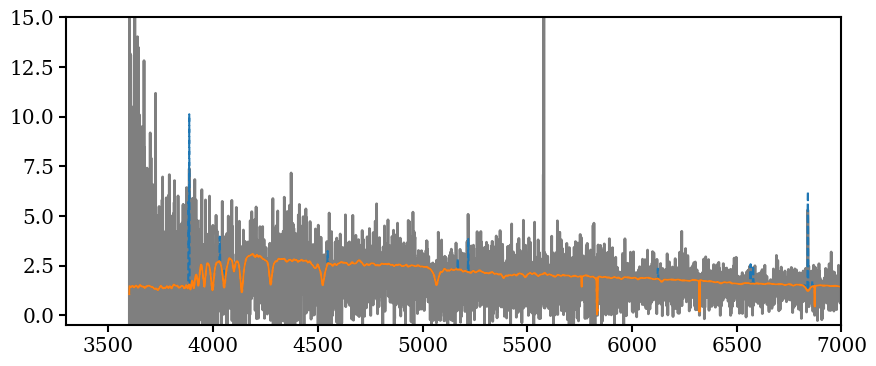

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


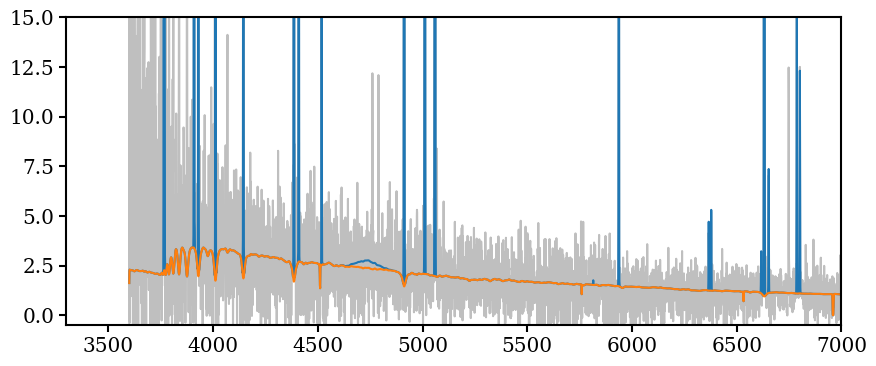

In [126]:

plt.figure(figsize = (10,4))
plt.plot(h5_wave, h5_flux[h5_id_low_ew],color="k",alpha=0.5,lw=2)

plt.plot(wavelength, model_data_low_ew[idx_low_ew][2] + model_data_low_ew[idx_low_ew][0],ls="--")
plt.plot(wavelength, model_data_low_ew[idx_low_ew][0])

plt.legend()
plt.ylim([-0.5,15])
plt.xlim([3300,7000])
plt.show()


###


plt.figure(figsize = (10,4))
plt.plot(h5_wave, h5_flux[h5_id_hi_ew],color="k",alpha=0.25)

plt.plot(wavelength, model_data_hi_ew[idx_hi_ew][2] + model_data_hi_ew[idx_hi_ew][0])
plt.plot(wavelength, model_data_hi_ew[idx_hi_ew][0])

plt.legend()
plt.ylim([-0.5,15])
plt.xlim([3300,7000])
plt.show()



### K corrections and bass -> decam -> sdss corrections!!

In [141]:
# lowz_diffs = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/model_photometry_diffs_LOWZ.fits")
# lowz_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_lowz_filter_zsucc_zrr03_INT_V2_NEBCORR.fits")
lowz_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_bgs_bright_filter_zsucc_zrr02_allfracflux_INT_V2_NEBCORR.fits")


In [142]:
snr_mask = (lowz_cat["HALPHA_EW"] * np.sqrt(lowz_cat["HALPHA_EW_IVAR"])) > 5
lowz_cat = lowz_cat[snr_mask]

In [143]:
np.median(lowz_cat["LOGM_M24_FIDU_CORR"] - lowz_cat["LOGM_M24_FIDU"])

-0.08053997647477917

In [155]:
lowz_cat["LOGM_M24_FIDU"].max()

9.499969294211642

In [156]:
lowz_cat["LOGM_M24_FIDU_CORR"].max()

9.249996931075698

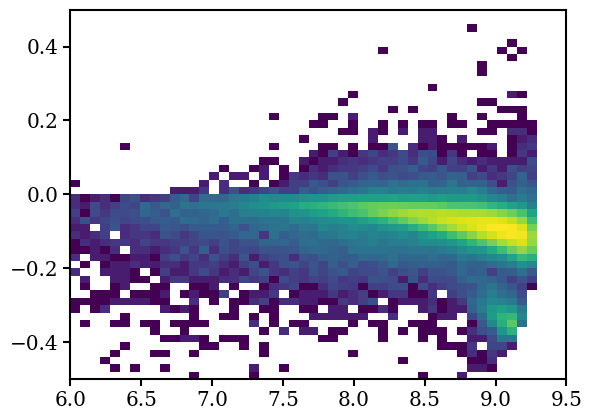

In [157]:
plt.hist2d(lowz_cat["LOGM_M24_FIDU_CORR"], lowz_cat["LOGM_M24_FIDU_CORR"] - lowz_cat["LOGM_M24_FIDU"],range=((6,9.5),(-.5,0.5)),
          bins=50,norm=LogNorm() )
plt.xlim([6,9.5])
plt.show()

In [149]:
## PLOT THESE K CORRECTIONS AS A FUNCTION OF REDSHIFT!!
#COMPRE WITH FIGURE 15 FROM BLANTON PAPER ...

In [150]:
gr_sdss_rest = lowz_cat["MAG_G_SDSS_Z0"]- lowz_cat["MAG_R_SDSS_Z0"] 

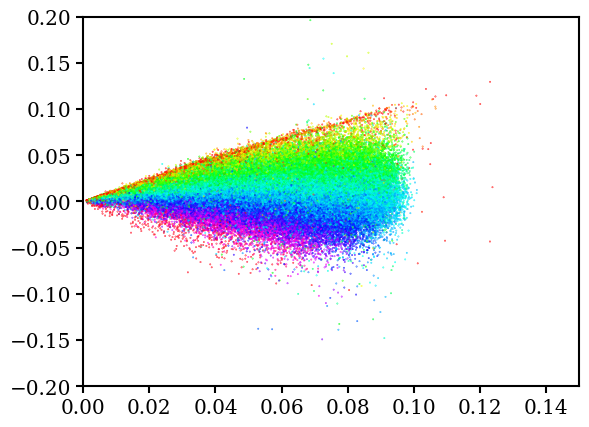

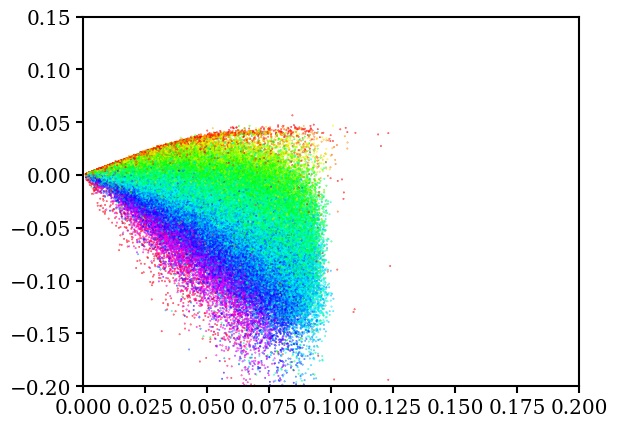

In [152]:
plt.scatter(lowz_cat["Z"],lowz_cat["DELTA_MAG_R_KCORR"] ,s=0.1, c= gr_sdss_rest, cmap="hsv",vmin=0,vmax=0.75)
plt.xlim([0,0.15])
plt.ylim([-0.2,0.2])
plt.show()

plt.scatter(lowz_cat["Z"],lowz_cat["DELTA_MAG_G_KCORR"] ,s=0.1, c= gr_sdss_rest, cmap="hsv",vmin=0,vmax=0.75)
plt.xlim([0,0.2])
plt.ylim([-0.2,0.15])
plt.show()

## how does this k correction apply to the model!!

Test: difference between sdss and decam filters as a function of color etc ... derive those transformations ...

the appendix b of dey et al. imaging paper has color transformations for stars. 

In [110]:
fastspec[fastspec["TARGETID"]==39627609633459177]
##this one has a big change!!

TARGETID,RA,DEC,SNR_B,SNR_R,SNR_Z,APERCORR,APERCORR_G,APERCORR_R,APERCORR_Z,OII_3726_FLUX,OII_3726_FLUX_IVAR,OII_3729_FLUX,OII_3729_FLUX_IVAR,OIII_4363_FLUX,OIII_4363_FLUX_IVAR,HEII_4686_FLUX,HEII_4686_FLUX_IVAR,HBETA_FLUX,HBETA_FLUX_IVAR,OIII_4959_FLUX,OIII_4959_FLUX_IVAR,OIII_5007_FLUX,OIII_5007_FLUX_IVAR,HEI_5876_FLUX,HEI_5876_FLUX_IVAR,NII_6548_FLUX,NII_6548_FLUX_IVAR,HALPHA_FLUX,HALPHA_FLUX_IVAR,HALPHA_BROAD_FLUX,HALPHA_BROAD_FLUX_IVAR,NII_6584_FLUX,NII_6584_FLUX_IVAR,SII_6716_FLUX,SII_6716_FLUX_IVAR,SII_6731_FLUX,SII_6731_FLUX_IVAR,SIII_9069_FLUX,SIII_9069_FLUX_IVAR,SIII_9532_FLUX,SIII_9532_FLUX_IVAR,HALPHA_BOXFLUX,HALPHA_BOXFLUX_IVAR,HALPHA_EW,HALPHA_EW_IVAR,ABSMAG01_SDSS_G,ABSMAG01_SDSS_R,ABSMAG01_SDSS_I,ABSMAG01_SDSS_Z,ABSMAG01_IVAR_SDSS_G,ABSMAG01_IVAR_SDSS_R,ABSMAG01_IVAR_SDSS_I,ABSMAG01_IVAR_SDSS_Z,DN4000,DN4000_OBS,DN4000_IVAR,DN4000_MODEL,VDISP,VDISP_IVAR,FLUX_SYNTH_G,FLUX_SYNTH_R,FLUX_SYNTH_Z,FLUX_SYNTH_SPECMODEL_G,FLUX_SYNTH_SPECMODEL_R,FLUX_SYNTH_SPECMODEL_Z,FLUX_SYNTH_PHOTMODEL_G,FLUX_SYNTH_PHOTMODEL_R,FLUX_SYNTH_PHOTMODEL_Z
int64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
39627609633459177,341.52673788903587,-7.488261655457936,1.5326889,3.0594904,3.3415115,1.6502779,2.3638256,1.6502779,1.3610095,205.31601,0.017725905,225.10349,0.016364502,49.53109,0.073029615,1.2513062,0.12891692,428.4677,0.03582112,943.57007,0.017968249,2719.152,0.0048778453,53.068806,0.27679494,7.491535,1.14502,1124.6558,0.04173435,0.0,0.0,21.603315,0.8622107,45.567715,0.71970785,35.23102,0.5107017,62.94404,0.7114664,0.0,0.0,1261.4995,0.03489473,493.75052,0.0056764935,-15.50298,-15.208447,-15.695561,-15.225821,109452.87,44290.97,44290.97,14554.279,1.3739768,0.7720017,177.38449,1.1095822,125.0,0.0,12.789469,11.093059,9.699559,15.087398,11.712235,10.316248,15.191885,18.153032,18.450108


'/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v2.1/healpix/main/bright/0/0/fastspec-main-bright-0.fits.gz'

The thing to test is whether the change in magnitude inferred from best fit templates is same as data minus emission model?

## Effect of nebular emission lines on spectra!!

This would be hard to do for shredded galaxies or objects with significant SED variation ... but is more meant to show the level of effect one would expect ...
This is especialyl because the M24 stellar mass method was not trained on spectra with emission line so systematics 

In [17]:
## I think one excersie would be to focus on BGS Bright galaxies, take galaxies in bins of Halpha EW

## that probably traces g-r pretty well..
gr = main["MAG_G"].data - main["MAG_R"].data

In [ ]:
## essentially in bins of Halpha EW, fit the stellar continuum and subtract the 

/tmp/ipykernel_177117/1828849967.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.hist2d(np.log10(fastspec["HALPHA_EW"]), gr,range=((0.1,2),(0,0.8)), bins=50,norm=LogNorm() )
/tmp/ipykernel_177117/1828849967.py:1: RuntimeWarning: invalid value encountered in log10
  plt.hist2d(np.log10(fastspec["HALPHA_EW"]), gr,range=((0.1,2),(0,0.8)), bins=50,norm=LogNorm() )


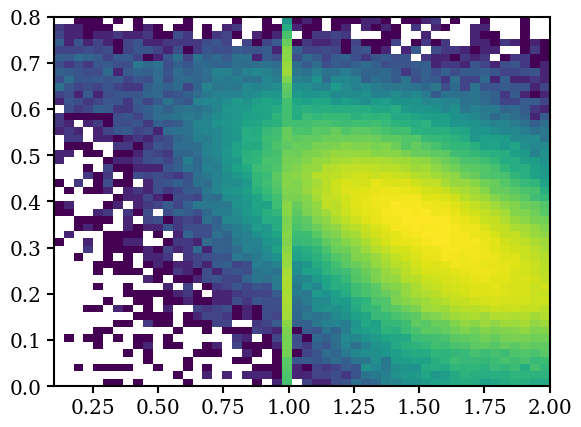

In [20]:
plt.hist2d(np.log10(fastspec["HALPHA_EW"]), gr,range=((0.1,2),(0,0.8)), bins=50,norm=LogNorm() )
plt.xlim(0.1,2)
plt.show()

In [3]:
stack_spec = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/scratch/stacked_flux_ew.npy")
wave = np.load("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/scratch/stacked_wave_ew.npy")

In [4]:
## fit fastspec to it!!
fspec_stack_out = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/nebular_mstar/fastspec_stack_halpha_ew_bins.fits"
fspec_cat = Table.read(fspec_stack_out, hdu="FASTSPEC")
specphot_cat = Table.read(fspec_stack_out, hdu="SPECPHOT")



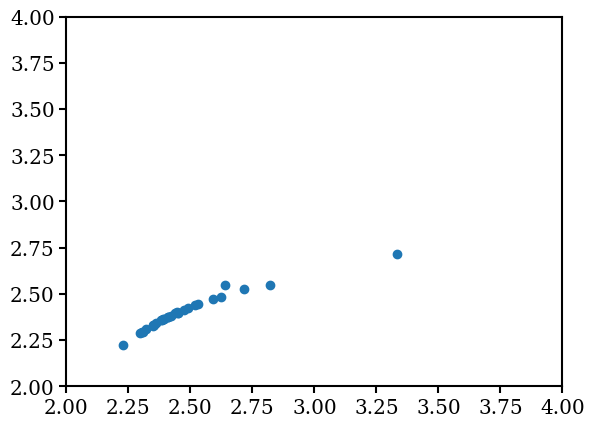

In [11]:

#### confirm how this plays for the actual observed galaxies!

plt.scatter(specphot_cat["FLUX_SYNTH_SPECMODEL_G"].data, specphot_cat["FLUX_SYNTH_PHOTMODEL_G"].data)
plt.xlim([2,4])
plt.ylim([2,4])
plt.show()

In [85]:
halpha_ew_bins = np.array(fspec_cat["HALPHA_EW"])

In [86]:
import numpy as np
import fitsio
import matplotlib.pyplot as plt

# ----- File paths -----
# stackfile = '/path/to/your/stacked_spectra.fits'   # input stacked spectra

only_continuum = []
both_emi_cont = []

for bin_idx in range(len(fspec_cat)):
# for bin_idx in range(2):
    
    
    flux = stack_spec[bin_idx]
    
    # ----- Read the model from the stackfit output -----
    models, hdr = fitsio.read(fspec_stack_out, 'MODELS', header=True)
    modelwave = hdr['CRVAL1'] + np.arange(hdr['NAXIS1']) * hdr['CDELT1']
    
    # models shape: [nobj, 3, nwave]
    #   models[idx, 0, :] = stellar continuum
    #   models[idx, 1, :] = smooth (non-parametric) continuum
    #   models[idx, 2, :] = emission-line model
    continuum       = models[bin_idx, 0, :]
    smooth_continuum = models[bin_idx, 1, :]
    emlines         = models[bin_idx, 2, :]
    full_model      = continuum + smooth_continuum + emlines
    
    # # ----- Plot 1: Full spectrum + model -----
    # fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    # ax1.plot(wave, flux, color='gray', alpha=0.5, lw=0.8, label='Data')
    # ax1.plot(modelwave, continuum, color='blue', lw=1, label='Stellar Continuum')
    # ax1.plot(modelwave, continuum + smooth_continuum, color='orange', lw=1,
    #          ls='--', label='Continuum + Smooth')
    # ax1.plot(modelwave, full_model, color='red', lw=1,ls="-", label='Full Model')
    # ax1.legend(fontsize=9, loc='upper right')
    # ax1.set_ylabel(r'Flux ($10^{-17}$ erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)')
    # ax1.set_title('Stackfit Result')
    # ax1.set_xlim(3000, 9000)
    
    # # residual
    # ax2.plot(modelwave, continuum + smooth_continuum, color='gray', alpha=0.5, lw=0.8)
    # ax2.axhline(0, color='k', ls='--', lw=0.5)
    # ax2.set_ylabel('Residual')
    # ax2.set_xlabel(r'Wavelength ($\AA$)')
    # ax2.set_xlim(3000, 9000)
    
    # plt.tight_layout()
    # plt.show()

    only_continuum.append(continuum + smooth_continuum)
    both_emi_cont.append( full_model )
    
    


/tmp/ipykernel_237338/860321282.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("viridis_r")


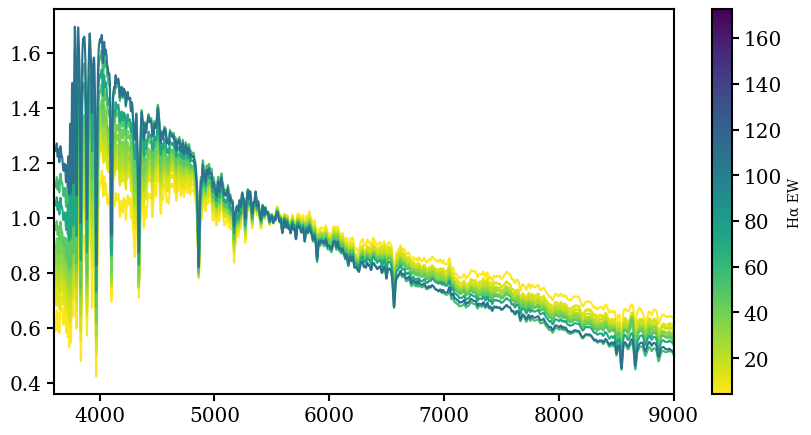

In [87]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import numpy as np

fig, ax = plt.subplots(figsize=(10,5))

# Normalize EW values
norm = colors.Normalize(
    vmin=np.min(halpha_ew_bins),
    vmax=np.max(halpha_ew_bins)
)

cmap = cm.get_cmap("viridis_r")

for i in range(len(only_continuum)):
    if i % 2 == 0:
        color = cmap(norm(halpha_ew_bins[i]))
        ax.plot(modelwave, only_continuum[i], color=color)

ax.set_xlim([3600, 9000])

# Create ScalarMappable
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])   # needed for older matplotlib versions

fig.colorbar(sm, ax=ax, label="Hα EW")

plt.show()

In [12]:
## compute photometry of and colors of these objects!!
## see how different the photometry is with and without emission lines!!
import speclite
from speclite import filters

decam_g = speclite.filters.load_filters('decamDR1noatm-g')
decam_r = speclite.filters.load_filters('decamDR1noatm-r')

r_only_cont = []
g_only_cont = []

r_full_emi = []
g_full_emi = []

for i in trange(len(only_continuum)):

    #compute the magnitude of this spectra
    wlen = modelwave * u.Angstrom
    
    flux_cont = only_continuum[i] * u.erg / (u.cm**2 * u.s * u.Angstrom)
    flux_full = both_emi_cont[i] * u.erg / (u.cm**2 * u.s * u.Angstrom)
    
    mags_g_cont = decam_g.get_ab_magnitudes(flux_cont, wlen)["decamDR1noatm-g"]
    mags_r_cont = decam_r.get_ab_magnitudes(flux_cont, wlen)["decamDR1noatm-r"]

    mags_g_full = decam_g.get_ab_magnitudes(flux_full, wlen)["decamDR1noatm-g"]
    mags_r_full = decam_r.get_ab_magnitudes(flux_full, wlen)["decamDR1noatm-r"]

    r_full_emi.append( mags_r_full )
    g_full_emi.append( mags_g_full )

    r_only_cont.append(  mags_r_cont )
    g_only_cont.append( mags_g_cont )
    


g_only_cont = np.array(g_only_cont)
r_only_cont = np.array(r_only_cont)

g_full_emi = np.array(g_full_emi)
r_full_emi = np.array(r_full_emi)




100%|██████████| 30/30 [00:00<00:00, 643.51it/s]


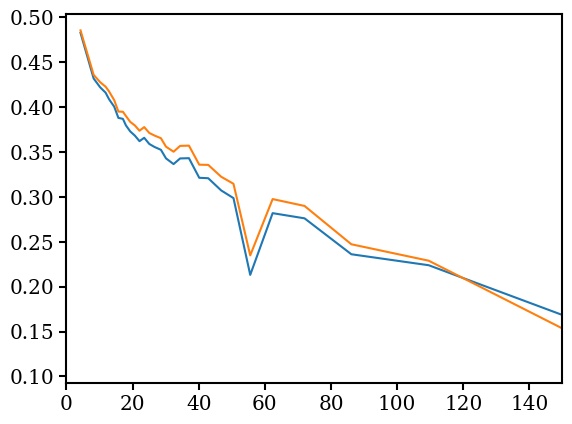

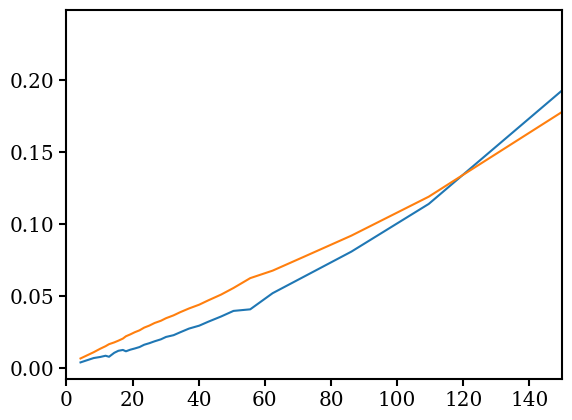

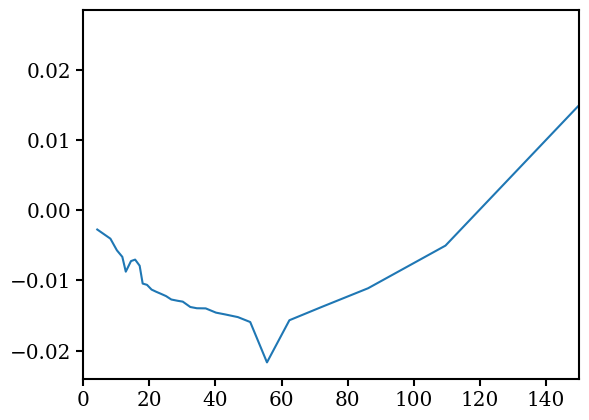

In [88]:
plt.plot(halpha_ew_bins, g_only_cont- r_only_cont )
plt.plot(halpha_ew_bins, g_full_emi- r_full_emi )
plt.xlim([0,150])
plt.show()
###

plt.plot(halpha_ew_bins, g_only_cont- g_full_emi )
plt.plot(halpha_ew_bins, r_only_cont- r_full_emi )
plt.xlim([0,150])
plt.show()


plt.plot(halpha_ew_bins, (g_only_cont- r_only_cont) - (g_full_emi- r_full_emi)  )
plt.xlim([0,150])
plt.show()



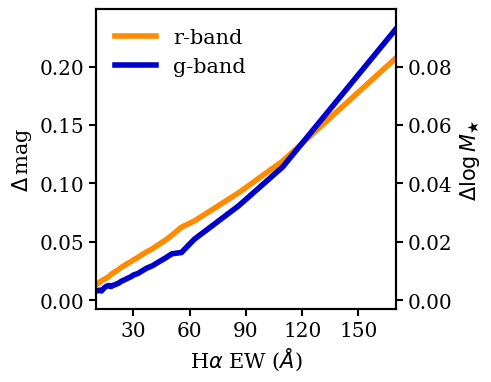

In [95]:
fig, ax = make_subplots(ncol=1, nrow=1, return_fig=True)
ax[0].plot(halpha_ew_bins, r_only_cont - r_full_emi, color="darkorange", lw=4, label="r-band")
ax[0].plot(halpha_ew_bins, g_only_cont - g_full_emi, color="mediumblue", lw=4, label="g-band")
ax[0].set_ylabel(r"$\Delta\,$mag", fontsize=15)
ax[0].set_xlim([10, 170])
ax[0].set_xticks([30, 60, 90, 120, 150])
ax[0].set_xlabel(r"H$\alpha$ EW ($\AA$)", fontsize=15)
ax[0].legend(frameon=False, fontsize=15)

# Add second y-axis
ax2 = ax[0].twinx()
y1_min, y1_max = ax[0].get_ylim()
ax2.set_ylim(y1_min * 0.4, y1_max * 0.4)
ax2.set_ylabel(r"$\Delta \log M_{\bigstar}$", fontsize=15)

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/stellar_mass_est_neb.pdf",bbox_inches="tight")
plt.show()

In [ ]:
## we parametrize this 

In [161]:
snr_cut = fastspec["HALPHA_EW"] * np.sqrt(fastspec["HALPHA_EW_IVAR"])

(5.0, 170.0)

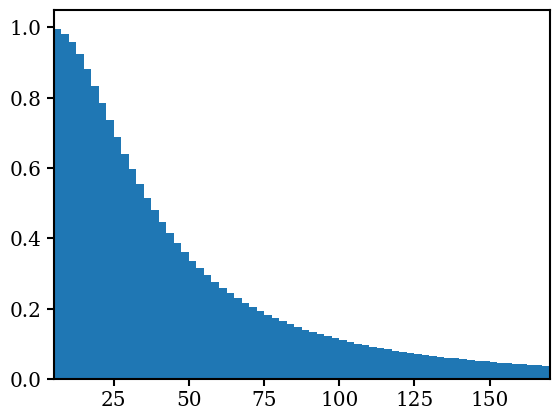

In [163]:
plt.hist(np.array(fastspec["HALPHA_EW"][snr_cut > 3]),range=(0,500),bins=200,density=True,cumulative=-1)
plt.xlim([5,170])

In [167]:
len(fastspec["HALPHA_EW"][snr_cut > 3])

302133

In [168]:
len(fastspec["HALPHA_EW"][(snr_cut > 3) & (fastspec["HALPHA_EW"] > 150)])

15696

In [169]:
15696/302133

0.05195063101349406

In [171]:
np.median(fastspec["HALPHA_EW"][(snr_cut > 3)])

/global/common/software/desi/perlmutter/desiconda/20240425-2.2.0/conda/lib/python3.10/site-packages/numpy/core/fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)


36.152503967285156

Comparing the different stellar mass estimates!!

Compare only objects from BGS and LOWZ. No ELG. Also show median value with 16-84 percentile error bar at fixed points?

TODO: To FASTSPEC add stellar mass estimates and rename it to some other HDU? Also, move the SAGA stellar mass to a different 


In [2]:
# filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# # Option 1: load the MAIN extension directly as an Astropy Table
# main =  Table.read(filename, hdu="MAIN")


##load the bgs bright, faint and lowz catalog and select only the clean objects
bgsb_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_bgs_bright_filter_zsucc_zrr02_allfracflux_INT_V2_NEBCORR.fits")
bgsf_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_bgs_faint_filter_zsucc_zrr03_allfracflux_INT_V2_NEBCORR.fits")
lowz_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_lowz_filter_zsucc_zrr03_INT_V2_NEBCORR.fits")

def process_cat(temp):
    mask = (temp["FRACFLUX_G"] < 0.2) & (temp["FRACFLUX_R"] < 0.2) & (temp["FRACFLUX_Z"] < 0.2) #& (temp["LOGM_M24_FIDU_NEBCORR_ERR"] < 0.5)
    temp_f = temp[mask]["TARGETID","RA","DEC","DIST_MPC_FIDU", "LOGM_M24_FIDU_NEBCORR"]
    print(len(temp), len(temp_f) )
    return temp_f


In [118]:
bgsb_cat_i = process_cat(bgsb_cat)
bgsf_cat_i = process_cat(bgsf_cat)
lowz_cat_i = process_cat(lowz_cat)

main =  vstack([bgsb_cat_i, bgsf_cat_i, lowz_cat_i])

169313 145699
54199 50318
39955 38193


In [5]:
np.sum(bgsb_cat["is_south"])

119944

In [119]:
len(main)

234210

In [46]:
from desi_lowz_funcs import g_kcorr

d_in_pc = main["LUMI_DIST_MPC"].data * 1e6
gr = main["MAG_G"].data - main["MAG_R"].data
kg = g_kcorr(gr,main["Z_CMB"].data )

main_absmag_g = main["MAG_G"].data + 5 - 5*np.log10(d_in_pc) - kg
    

In [47]:
np.sum((main_absmag_g > -18.5))/len(main)

0.9898612775326106

In [48]:

main = main[(main["SAMPLE"] != "ELG") & (main["DWARF_MASKBIT"] == 0) & (main_absmag_g > -18.5)]


In [49]:
main_tractor_og = main[ (main["MAG_TYPE"] == "TRACTOR_OG") ]

In [50]:
print(len(main), len(main_tractor_og))

248578 236947


In [63]:
temp = main[main["LOG_MSTAR_M24"] > 9.2]

In [67]:
# np.median(temp["MAG_G"].data - temp["MAG_R"].data) <- 0.47

In [120]:
##match with the entire catalog
## what does this catalog assume for cosmology?
## According to their paper, they WMAP7 flat cosmology .. how does that impact distance??
gswlc_cat = ascii.read("/pscratch/sd/v/virajvm/desi2_lowz_data/catalogs/GSWLC-X2.dat")
iron = SkyCoord(np.array(main["RA"])*u.degree, np.array(main["DEC"])*u.degree  )
gswlc = SkyCoord(np.array(gswlc_cat["RA"])*u.degree, np.array(gswlc_cat["DEC"])*u.degree  )
idx, d2d, _ = iron.match_to_catalog_sky(gswlc)
main_gswlc_match = main[d2d.arcsec < 1]
gswlc_match = gswlc_cat[idx][d2d.arcsec < 1]

print(len(main_gswlc_match))

##these are stellar masses from Hu Zhou XMPG paper. They also use CIGALE here and no AGN is used
#they assume flat ΛCDM cosmology with ΩΛ = 0.7, Ωm = 0.3, and H0 = 70 km s−1 Mpc−1
hu_cat= Table.read("/global/cfs/cdirs/desi/users/dscholte/data_to_share/sample_catalog_viraj_29052024.fits")
iron = SkyCoord(np.array(main["RA"])*u.degree, np.array(main["DEC"])*u.degree  )
hu = SkyCoord(np.array(hu_cat["RA"])*u.degree, np.array(hu_cat["DEC"])*u.degree  )
idx, d2d, _ = iron.match_to_catalog_sky(hu)
main_hu_match = main[d2d.arcsec < 1]
hu_match = hu_cat[idx][d2d.arcsec < 1]

print(len(main_hu_match))



4570
109505


In [52]:
##FASTSPECFIT
fspec_save_path  = "/pscratch/sd/v/virajvm/catalog/fastspec_mstar_match.fits"
overwrite=True
if os.path.exists(fspec_save_path.replace(".fits","_fspec.npy")) and overwrite==False:
    print("Reading pre-matched fastspecfit catalog!")
    fspec_mstar_f = np.load(fspec_save_path.replace(".fits","_fspec.npy"))

    main_fspec_match = Table.read(fspec_save_path.replace(".fits","_main.fits"))
    
else:
    print("Reading fastspecfit!")
    iron_vac = fits.open("/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v2.1/catalogs/fastspec-iron.fits")
    fspec_mstar = iron_vac[1].data["LOGMSTAR"]
    fspec_ra = iron_vac[2].data["RA"]
    fspec_dec = iron_vac[2].data["DEC"]
    catalog = SkyCoord(ra= fspec_ra* u.degree, dec= fspec_dec*u.degree )
    c = SkyCoord(ra=np.array(main["RA"])*u.degree, dec=np.array(main["DEC"])*u.degree )
    idx, d2d, d3d = c.match_to_catalog_sky(catalog)
    fspec_mstar_f = fspec_mstar[idx][d2d.arcsec < 1]
    main_fspec_match = main[d2d.arcsec < 1]
    
    print("Finished matching fastspecfit!")

    np.save(fspec_save_path.replace(".fits","_fspec.npy"),  fspec_mstar_f)
    main_fspec_match.write(fspec_save_path.replace(".fits","_main.fits"),overwrite=True)
    
print(f"Matched {len(fspec_mstar_f)} galaxies with fastspecfit")
    
## save these two matched catalogs so we do not have to always run this!!

Reading fastspecfit!
Finished matching fastspecfit!
Matched 236947 galaxies with fastspecfit


In [53]:
# #3 cross matching with COSMOS catalog
# ## need the photo-z to also be similar

# import fitsio

# cols = ["ALPHA_J2000", "DELTA_J2000", "lp_zBEST", "lp_mass_med", "lp_mass_best", "lp_zMinChi2", "lp_zPDF"]

# cosmos2020_cat = fitsio.read("/pscratch/sd/v/virajvm/catalog/COSMOS2020_FARMER_R1_v2.2_p3.fits", columns=cols)

# cosmos2020_cat = Table(cosmos2020_cat)

In [54]:
# iron = SkyCoord(np.array(main["RA"])*u.degree, np.array(main["DEC"])*u.degree  )
# c20 = SkyCoord(np.array(cosmos2020_cat["ALPHA_J2000"])*u.degree, np.array(cosmos2020_cat["DELTA_J2000"])*u.degree  )
# idx, d2d, _ = iron.match_to_catalog_sky(c20)
# main_cos20_match = main[d2d.arcsec < 1]
# cos20_match = cosmos2020_cat[idx][d2d.arcsec < 1]

# ## similar to zou et al 2024, let us identify objects with consistent redshifts
# good_mask = (np.abs(cos20_match["lp_zPDF"] - main_cos20_match["Z"]) / (1 + main_cos20_match["Z"]) < 0.01)

# print(np.sum(good_mask))

# main_cos20_match = main_cos20_match[good_mask]
# cos20_match = cos20_match[good_mask]



In [122]:
import cmasher as cmr
from scipy.stats import median_abs_deviation

def measure_bias_scatter(quant_1, quant_2):
    '''
    Meausure the median of quant_1 - quant_2 and the scatter in this difference. We restrict ourselves to objects
    '''

    quant_1f = quant_1[~np.isnan(quant_1) & ~np.isnan(quant_2) ]
    quant_2f = quant_2[~np.isnan(quant_2) & ~np.isnan(quant_2) ]

    med_val = np.median(quant_1f - quant_2f)
    scatters = quant_1f - quant_2f - med_val

    sigma =  median_abs_deviation(scatters, scale='normal')

    print(med_val, sigma)
    return med_val, sigma


In [123]:
from desi_lowz_funcs import make_alternating_plot

NameError: name 'main_fspec_match' is not defined

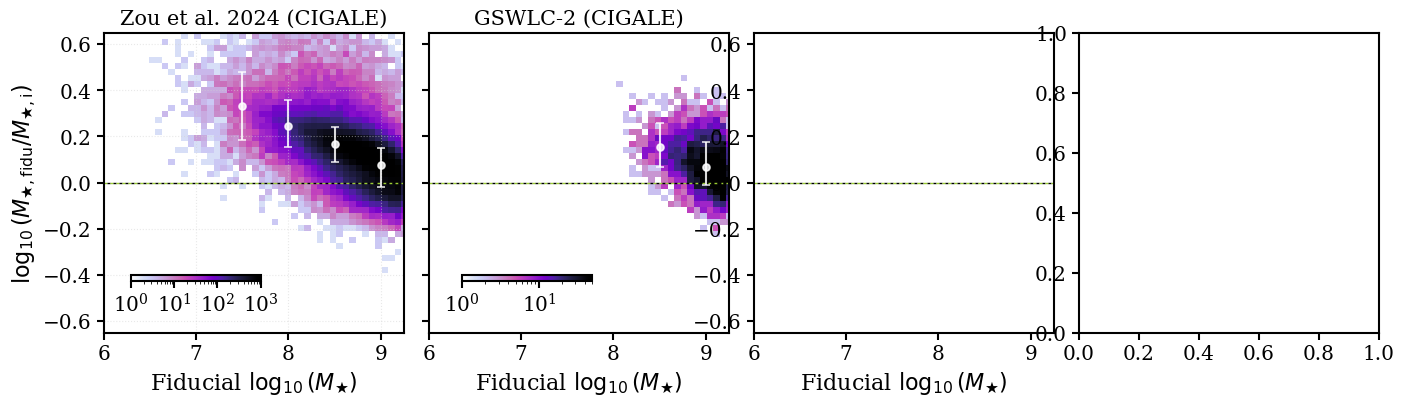

In [124]:
ax = make_subplots(ncol = 4,nrow = 1,col_spacing = 0.25)

title_size = 15

xmstar = "LOGM_M24_FIDU_NEBCORR" #"LOG_MSTAR_M24"



ylim = 0.65

cmap = cmr.gothic_r.copy()
cmap.set_under(alpha=0.)

####
xpos = 7.1
ypos = 6.25
fsize = 14

#the 0.03 offset is taking into account the differing cosmologies

ax_id = 0
ax[ax_id].set_title(r"Zou et al. 2024 (CIGALE)",fontsize = title_size )
h, xedges, yedges, im=ax[ax_id].hist2d(main_hu_match[xmstar],main_hu_match[xmstar] - (hu_match["LOGMSTAR_HU"] + 0.03),range= ( (6,9.5),(-ylim,ylim)),bins= 50,norm=LogNorm(vmin=1,vmax=1000) ,cmap=cmap, rasterized=True)

# bias, scatter = measure_bias_scatter(main_hu_match[xmstar].data,hu_match["LOGMSTAR_HU"] + 0.03)

# ax[ax_id].text( xpos,ypos,rf"b = {bias:.2f}, $\sigma$ = {scatter:.2f}",fontsize = fsize)

 # Create a colorbar
cbar = plt.colorbar(im, ax=ax[ax_id], orientation='horizontal', pad=0.05)
cbar.ax.set_position([
    0.04,   # Left position
    0.26,  # Top position
    ax[ax_id].get_position().width * 0.1,  # Width (40% of plot width)
    0.02  # Height (thin bar)
])

###

#the 0.03 offset is taking into account the differing cosmologies



ax_id = 1
ax[ax_id].set_title(r"GSWLC-2 (CIGALE)",fontsize = title_size )
h, xedges, yedges, im=  ax[ax_id].hist2d(main_gswlc_match[xmstar],main_gswlc_match[xmstar] - (gswlc_match["LOGMSTAR"] + 0.03),range= ( (6,9.5),(-ylim,ylim)),bins= 50,norm=LogNorm(vmin=1, vmax=50) ,cmap=cmap, rasterized=True)

# bias, scatter = measure_bias_scatter(main_gswlc_match[xmstar].data,gswlc_match["LOGMSTAR"].data + 0.03)
# ax[ax_id].text( xpos,ypos,rf"b = {bias:.2f}, $\sigma$ = {scatter:.2f}",fontsize = fsize)

 # Create a colorbar
cbar = plt.colorbar(im, ax=ax[ax_id], orientation='horizontal', pad=0.05)
cbar.ax.set_position([
    0.295,   # Left position
    0.26,  # Top position
    ax[ax_id].get_position().width * 0.1,  # Width (40% of plot width)
    0.02  # Height (thin bar)
])    

# #######
# # note that fastspecfit stellar masses are in h = 1 units, so we need to modify them!!
# hubble_val = 0.67 

# ax_id = 2
# ax[ax_id].set_title(r"Fastspecfit",fontsize = title_size )
# h, xedges, yedges, im =  ax[ax_id].hist2d(main_fspec_match[xmstar],main_fspec_match[xmstar] - (fspec_mstar_f - 2 * np.log10(hubble_val) ),range= ( (6,9.5),(-ylim,ylim)),bins= 50,norm=LogNorm(vmin=1, vmax=1000) ,cmap=cmap, rasterized=True)

# # bias, scatter = measure_bias_scatter(main_fspec_match[xmstar].data,fspec_mstar_f - 2 * np.log10(hubble_val))
# # ax[ax_id].text( xpos,ypos,rf"b = {bias:.2f}, $\sigma$ = {scatter:.2f}",fontsize = fsize)

# cbar = plt.colorbar(im, ax=ax[ax_id], orientation='horizontal', pad=0.05)
# cbar.ax.set_position([
#     0.545,   # Left position
#     0.26,  # Top position
#     ax[ax_id].get_position().width * 0.1,  # Width (40% of plot width)
#     0.02  # Height (thin bar)
# ])

# #######
# ##note that I am plotting the SAGA mass key here for, but am offseting it as I want to compare it with Bell et a. 2003 relation (see equation 1 in de los reyes et al. 2025)

# ax_id = 3
# ax[ax_id].set_title(r"Bell et al. 2003 ($g-r$ based)",fontsize = title_size )
# h, xedges, yedges, im =  ax[ax_id].hist2d(main[xmstar], main[xmstar] - (main["LOG_MSTAR_SAGA"] + (1.461 - 1.254) ) ,range= ( (6,9.5),(-ylim,ylim)),bins= 50,norm=LogNorm(vmin=1, vmax=1000) ,cmap=cmap, rasterized=True)
# # ax[ax_id].scatter(main_cos20_match[xmstar], cos20_match["lp_mass_med"])

# # bias,scatter = measure_bias_scatter(main[xmstar], main["LOG_MSTAR_SAGA"] + (1.461 - 1.254)) 
# # ax[ax_id].text( xpos,ypos,rf"b = {bias:.2f}, $\sigma$ = {scatter:.2f}",fontsize = fsize)

#  # Create a colorbar
# cbar = plt.colorbar(im, ax=ax[ax_id], orientation='horizontal', pad=0.05)
# cbar.ax.set_position([
#     0.795,   # Left position
#     0.26,  # Top position
#     ax[ax_id].get_position().width * 0.1,  # Width (40% of plot width)
#     0.02  # Height (thin bar)
# ])

for i,axi in enumerate(ax):
    axi.set_xlim([6,9.25])
    axi.set_ylim([-ylim,ylim])
    
    axi.set_xlabel(r"Fiducial $\log_{10}(M_{\bigstar})$",size= 16)
    ax[0].set_ylabel(r"$\log_{10}(M_{\bigstar, \rm fidu} / M_{\bigstar, \rm i})$",size= 16)
    ax[0].grid(ls = ":",color = "lightgrey",alpha = 0.5)
    
    xgrid = np.linspace(6,9.25,100)
    make_alternating_plot(ax[i],xgrid,0*xgrid,dash_len=1,color_1="yellowgreen",color_2="k",lw=1)

    # --- binned median + 16/84 percentile error bars ---
    # Reconstruct the y-data for each panel
    if i == 0:
        xdata = main_hu_match[xmstar]
        ydata = main_hu_match[xmstar] - (hu_match["LOGMSTAR_HU"] + 0.03)
    elif i == 1:
        xdata = main_gswlc_match[xmstar]
        ydata = main_gswlc_match[xmstar] - (gswlc_match["LOGMSTAR"] + 0.03)
    elif i == 2:
        xdata = main_fspec_match[xmstar]
        ydata = main_fspec_match[xmstar] - (fspec_mstar_f - 2 * np.log10(hubble_val))
    elif i == 3:
        xdata = main[xmstar]
        ydata = main[xmstar] - (main["LOG_MSTAR_SAGA"] + (1.461 - 1.254))

    xdata = np.asarray(xdata)
    ydata = np.asarray(ydata)

    bin_width = 0.2
    for xcen in [7.5,8,8.5, 9]:
        mask = (xdata >= xcen - bin_width / 2) & (xdata < xcen + bin_width / 2)
        if mask.sum() > 100:
            med = np.median(ydata[mask])
            p16 = np.percentile(ydata[mask], 16)
            p84 = np.percentile(ydata[mask], 84)

            if i == 3:
                axi.errorbar(xcen, med,
                             yerr=[[med - p16], [p84 - med]],
                             fmt='none', color='white',
                             ecolor='white', elinewidth=1.5, capsize=3, zorder=10, alpha=0.85)
            else:
                axi.errorbar(xcen, med,
                             yerr=[[med - p16], [p84 - med]],
                             fmt='o', color='white', markeredgecolor='white',
                             markeredgewidth=1.2, markersize=5, alpha=0.85,
                             ecolor='white', elinewidth=1.5, capsize=3, zorder=10)

    if i != 0:
        axi.set_yticklabels([])

# plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/stellar_mass_comp.pdf",bbox_inches="tight")
plt.show()



In [58]:
# #this
# gr_i = 0.2
# absmag_g_i = -18.5
# print(1.986 + 1.315*gr_i - 0.365 * (absmag_g_i))
# print(1.598 + 1.347*gr_i - 0.5 * (absmag_g_i))


In [ ]:
## what happens to the above plot if we were to remove the contribution of HALPHA_EW?
## and see what happens to these plots? Because we are currently over-estimating, but 
## the effect should be order ~0.05?

In [203]:
## how much does the luminosity distance differ between these different cosmologies over our redshift range of interest?

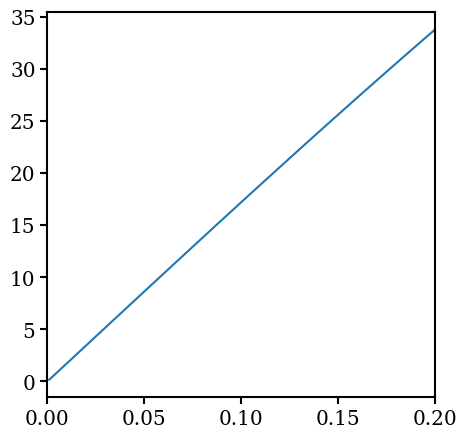

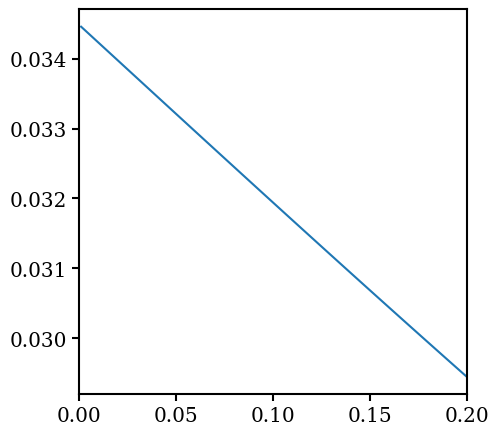

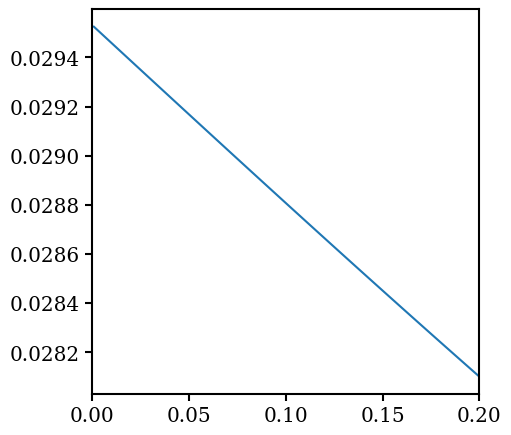

In [276]:
from astropy.cosmology import Planck18, WMAP7, FlatLambdaCDM

cosmos_flat = FlatLambdaCDM(H0=70, Om0=0.3)

zred_bins = np.linspace(0.001, 0.2,100)

p18_DLs = Planck18.luminosity_distance(zred_bins).value
w7_DLs = WMAP7.luminosity_distance(zred_bins).value
flat_DLs = cosmos_flat.luminosity_distance(zred_bins).value


# their cosmology (example)


plt.figure(figsize = (5,5))
plt.plot(zred_bins, p18_DLs -  w7_DLs)
plt.xlim([0,0.2])
plt.show()

##how much does this translate to an offset in absolute magnitudes
plt.figure(figsize = (5,5))
plt.plot(zred_bins, 0.4 * 5 * np.log10(p18_DLs / w7_DLs  ) )
plt.xlim([0,0.2])
plt.show()

plt.figure(figsize = (5,5))
plt.plot(zred_bins, 0.4 * 5 * np.log10(p18_DLs / flat_DLs  ) )
plt.xlim([0,0.2])
plt.show()




In [96]:
### ahhh how does the updated stellar mass relation from Mia de los reyes compare to the old one I was using!!

In [127]:
from desi_lowz_funcs import get_stellar_mass_mia

main = main[main["DWARF_MASKBIT"] == 0]

gr_color = main["MAG_G"].data - main["MAG_R"].data

g_mag = main["MAG_G"].data
d_in_mpc = main["LUMI_DIST_MPC"].data
zreds = main["Z_CMB"].data

from desi_lowz_funcs import g_kcorr

d_in_pc = d_in_mpc * 1e6
kg = g_kcorr(gr_color,zreds)

Mg = g_mag + 5 - 5*np.log10(d_in_pc) - kg


In [128]:
log_mstar_OLD = (1.433 * gr_color) + 0.00153 * (Mg**2) - (0.335 * Mg) + 2.072

log_mstar_NEW = get_stellar_mass_mia(gr_color, g_mag, zreds, d_in_mpc=d_in_mpc, input_zred=False)

In [129]:
len(log_mstar_NEW[log_mstar_NEW < 9.25])

212708

In [131]:
len(log_mstar_NEW)

218926

In [132]:
212708/218926

0.9715977088148506